In [1]:
# Base TWFE: log(ZHVI_mt) ~ post_mt + metro FE + month FE  (clustered by metro & time)

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"

# --- Load + minimal clean ---
df = pd.read_csv(CSV)

# keep essential cols if present
need = ["metro_name","ym","zhvi","open_ym"]
missing = [c for c in need if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# window and parsing
df = df.copy()
df["ym"] = pd.to_datetime(df["ym"] + "-01", errors="coerce")
df["open_ym_dt"] = pd.to_datetime(df["open_ym"].astype(str) + "-01", errors="coerce")

# keep 2000–2025 (inclusive)
df = df[(df["ym"] >= "2000-01-01") & (df["ym"] <= "2025-12-01")].copy()

# outcome
df["zhvi"] = pd.to_numeric(df["zhvi"], errors="coerce")
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# treatment: post = 1 on/after opening month; 0 otherwise; stays 0 if no opening
df["post"] = ((df["open_ym_dt"].notna()) & (df["ym"] >= df["open_ym_dt"])).astype(int)

# panel index
df = df.set_index(["metro_name","ym"]).sort_index()

# --- Estimate ---
mod = PanelOLS(
    df["ln_zhvi"],
    df[["post"]],
    entity_effects=True,   # metro FE
    time_effects=True      # month FE
)
res = mod.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_zhvi   R-squared:                        0.0012
Estimator:                   PanelOLS   R-squared (Between):              0.0004
No. Observations:              105824   R-squared (Within):               0.0041
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.0004
Time:                        16:06:52   Log-likelihood                  8.41e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      129.87
Entities:                         377   P-value                           0.0000
Avg Obs:                       280.70   Distribution:                F(1,105138)
Min Obs:                       116.00                                           
Max Obs:                       309.00   F-statistic (robust):             3.5800
                            

In [2]:
# --- Paths ---
PATH = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# 1) Load + basic tidy
df = pd.read_csv(PATH)

need = {"metro_name","ym","zhvi","open_ym","totalcost2020"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Dates
df["t"] = pd.to_datetime(df["ym"] + "-01", errors="coerce")
open_dt = pd.to_datetime(df["open_ym"].astype("string") + "-01", errors="coerce")
df["open_t"] = open_dt.fillna(pd.Timestamp("2260-01-01"))  # far future for untreated

# 2) Post (1 from opening month onward; 0 otherwise)
df["post"] = (df["t"] >= df["open_t"]).astype(int)

# 3) Outcome
df["zhvi"] = pd.to_numeric(df["zhvi"], errors="coerce")
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# 4) Use TOTAL COST in LEVELS (millions), NOT centered or logged
df["totalcost2020"] = pd.to_numeric(df["totalcost2020"], errors="coerce")

# One cost per metro (your build keeps earliest opening); keep >0 and merge back
metro_cost = (
    df.loc[df["totalcost2020"].gt(0), ["metro_name","totalcost2020"]]
      .drop_duplicates("metro_name")
)

# For metros without a reported cost, set 0 so the interaction becomes 0
df = df.merge(metro_cost, how="left", on="metro_name", suffixes=("","_metro"))
df["totalcost_used"] = df["totalcost2020_metro"].fillna(0.0)

# 5) Interaction: post × total cost (levels, in MILLIONS)
df["post_x_totalcost"] = df["post"] * df["totalcost_used"]

# 6) Keep 2000–2025
df = df[(df["t"] >= "2000-01-01") & (df["t"] <= "2025-12-01")].copy()

# 7) TWFE with two-way clustered SEs (metro & month)
panel = df.set_index(["metro_name","t"]).sort_index()
model = PanelOLS(
    dependent=panel["ln_zhvi"],
    exog=panel[["post","post_x_totalcost"]],
    entity_effects=True,   # metro FE
    time_effects=True      # month FE
)
res = model.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res.summary)

# Quick interpretations (cost in MILLIONS)
beta  = res.params.get("post", np.nan)
gamma = res.params.get("post_x_totalcost", np.nan)

mean_cost = metro_cost["totalcost2020"].mean() if not metro_cost.empty else np.nan

print("\nINTERPRETATION HELP (cost in $M):")
if pd.notna(beta):
    print(f"- Post effect at $0M (baseline of this spec): {100*(np.exp(beta)-1):.2f}%")
if pd.notna(beta) and pd.notna(gamma) and pd.notna(mean_cost):
    eff_mean = beta + gamma*mean_cost
    print(f"- Post effect at mean cost (${mean_cost:,.0f}M): {100*(np.exp(eff_mean)-1):.2f}%")
    print(f"- Extra effect per +$100M above mean: ~{100*(np.exp(gamma*100)-1):.2f}% (exact)")
    print(f"  (Small-change approx per +$100M: ~{100*(gamma*100):.2f}%)")

# OPTIONAL: If you prefer nicer scaling, you can instead create:
# df['totalcost_100m'] = df['totalcost_used'] / 100.0
# df['post_x_totalcost_100m'] = df['post'] * df['totalcost_100m']
# ...and run with exog=['post','post_x_totalcost_100m'] so gamma reads as “per +$100M”.

                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_zhvi   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:              105824   R-squared (Within):               0.0043
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.0004
Time:                        16:06:54   Log-likelihood                 8.413e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      87.676
Entities:                         377   P-value                           0.0000
Avg Obs:                       280.70   Distribution:                F(2,105137)
Min Obs:                       116.00                                           
Max Obs:                       309.00   F-statistic (robust):             9.1195
                            

In [3]:
# --- Paths ---
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# 1) Load + basic tidy
df = pd.read_csv(CSV)

need = {"metro_name","ym","zhvi","open_ym","totalcost2020","publiccost2020"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Dates
df["t"]      = pd.to_datetime(df["ym"] + "-01", errors="coerce")
open_dt      = pd.to_datetime(df["open_ym"].astype("string") + "-01", errors="coerce")
df["open_t"] = open_dt.fillna(pd.Timestamp("2260-01-01"))  # far future if never opens

# 2) Post switch
df["post"] = (df["t"] >= df["open_t"]).astype(int)

# 3) Outcome
df["zhvi"] = pd.to_numeric(df["zhvi"], errors="coerce")
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# 4) Intensity variables (LEVELS, millions of 2020$)
df["totalcost2020"]  = pd.to_numeric(df["totalcost2020"],  errors="coerce")
df["publiccost2020"] = pd.to_numeric(df["publiccost2020"], errors="coerce")

# Public vs Private indicator: 1 if any public funding on the opening project, else 0
# (metros with no opening get 0)
df["publicAny"] = ((df["publiccost2020"] > 0) & df["open_ym"].notna()).astype(int)

# Use level cost; fill NaN with 0 so untreated rows don't create NaNs in interactions
df["totalcost_lvl"] = df["totalcost2020"].fillna(0.0)

# Interactions
df["post_x_totalcost"] = df["post"] * df["totalcost_lvl"]
df["post_x_publicAny"] = df["post"] * df["publicAny"]

# 5) Keep 2000–2025 window
df = df[(df["t"] >= "2000-01-01") & (df["t"] <= "2025-12-01")].copy()

# 6) TWFE with two-way clustered SEs (metro & month)
panel = df.set_index(["metro_name","t"]).sort_index()
mod   = PanelOLS(
    dependent=panel["ln_zhvi"],
    exog=panel[["post","post_x_totalcost","post_x_publicAny"]],
    entity_effects=True,   # metro FE
    time_effects=True      # month FE
)
res = mod.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)
print(res.summary)

# 7) Handy interpretations (cost in MILLIONS)
b_post  = res.params.get("post", np.nan)
b_cost  = res.params.get("post_x_totalcost", np.nan)
b_pub   = res.params.get("post_x_publicAny", np.nan)

# A sensible cost to plug in (mean among treated metros)
mean_cost = (df.loc[df["totalcost2020"].gt(0), ["metro_name","totalcost2020"]]
               .drop_duplicates("metro_name")["totalcost2020"].mean())

if np.isfinite(mean_cost):
    eff_private = 100*(np.exp(b_post + b_cost*mean_cost) - 1)
    eff_public  = 100*(np.exp(b_post + b_cost*mean_cost + b_pub) - 1)
    print(f"\nMean total cost (treated metros): ${mean_cost:,.0f}M")
    print(f"Estimated post effect at mean cost — Private: {eff_private:.2f}%   Public: {eff_public:.2f}%")

# Per $100M change in budget (approx, small-change)
if np.isfinite(b_cost):
    print(f"Approx. extra post effect per +$100M: {100*(100*b_cost):.2f}%")

                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_zhvi   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):              0.0003
No. Observations:              105824   R-squared (Within):               0.0043
Date:                Wed, Apr 15 2026   R-squared (Overall):              0.0004
Time:                        16:06:56   Log-likelihood                 8.413e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      59.188
Entities:                         377   P-value                           0.0000
Avg Obs:                       280.70   Distribution:                F(3,105136)
Min Obs:                       116.00                                           
Max Obs:                       309.00   F-statistic (robust):             6.3155
                            

In [4]:
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# === 1. Load data ===
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"
df = pd.read_csv(CSV)

# === 2. Basic setup: ln_zhvi and first opening per metro ===
needed = ["metro_name", "ym", "zhvi", "open_ym"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Parse dates
df["ym"] = pd.to_datetime(df["ym"])
df["open_ym"] = pd.to_datetime(df["open_ym"])

# Keep only positive ZHVI and build log outcome
df = df[df["zhvi"] > 0].copy()
df["ln_zhvi"] = np.log(df["zhvi"])

# First opening month per metro (if any)
first_open_per_metro = (
    df.dropna(subset=["open_ym"])
      .groupby("metro_name")["open_ym"]
      .min()
)
df["first_open_ym"] = df["metro_name"].map(first_open_per_metro)

# === 3. Event time k in months ===
# Convert dates to "month number" = year*12 + month
ym_num = df["ym"].dt.year * 12 + df["ym"].dt.month
open_num = df["first_open_ym"].dt.year * 12 + df["first_open_ym"].dt.month

# raw_k: months relative to first opening
raw_k = ym_num - open_num  # NaN for never-treated metros

# Binning: core window [-60, +60], with tails folded into -60 and +60
k_binned = raw_k.copy()

# For treated metros only (where we have an opening)
treated_mask = ~df["first_open_ym"].isna()
k_binned = k_binned.where(treated_mask)  # NaN for never-treated

k_binned = k_binned.astype("float")  # keep as float; NaN stays NaN

# Fold tails
k_binned[treated_mask & (k_binned <= -60)] = -60
k_binned[treated_mask & (k_binned >=  60)] =  60

df["k_binned"] = k_binned

# === 4. Build event-time dummies (reference: k = -1) ===
event_ks = [k for k in range(-60, 61) if k != -1]

for k in event_ks:
    col = f"event_{k}"
    # KEY FIX: fill NaNs with False before astype(int)
    df[col] = (df["k_binned"] == k).fillna(False).astype(int)

# === 5. Set panel index ===
df = df.set_index(["metro_name", "ym"]).sort_index()

# Outcome
y = df["ln_zhvi"]

# Regressors: all event dummies
X = df[[f"event_{k}" for k in event_ks]]

# === 6. Event-study regression: ln_zhvi ~ sum_k θ_k * D_k + metro FE + month FE ===
mod_es = PanelOLS(y, X, entity_effects=True, time_effects=True)
res_es = mod_es.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)

print("\n=== Event Study: ln(ZHVI_mt) on event-time dummies ===")
print("Window: k in [-60, +60], with tails folded; reference period k = -1")
print("Two-way FE (metro & month), two-way clustered SEs (metro & month)\n")

# === 7. Build tidy event-time table ===
rows = []
for k in sorted(event_ks):
    var = f"event_{k}"
    if var in res_es.params.index:
        coef = res_es.params[var]
        se = res_es.std_errors[var]
        pval = res_es.pvalues[var]
        pct = 100 * (np.exp(coef) - 1)  # % vs k = -1
        rows.append({
            "k_months": k,
            "coef_log": coef,
            "se_log": se,
            "p_value": pval,
            "pct_change_vs_km1": pct
        })

es_table = pd.DataFrame(rows).sort_values("k_months")

print("Event-time coefficients (relative to k = -1):\n")
print(es_table.to_string(index=False))

print("\nNotes:")
print("- k_months is months relative to first opening (k = 0 is opening month).")
print("- k = -1 (month before opening) is the omitted reference category.")
print("- pct_change_vs_km1 is 100·(exp(θ_k) − 1): % change in ZHVI vs month before opening.")
print("- Never-treated metros are kept in the sample; all event dummies = 0 for them.")

/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_5170/3777890153.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = (df["k_binned"] == k).fillna(False).astype(int)
/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_5170/3777890153.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = (df["k_binned"] == k).fillna(False).astype(int)
/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_5170/3777890153.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 


=== Event Study: ln(ZHVI_mt) on event-time dummies ===
Window: k in [-60, +60], with tails folded; reference period k = -1
Two-way FE (metro & month), two-way clustered SEs (metro & month)

Event-time coefficients (relative to k = -1):

 k_months  coef_log   se_log  p_value  pct_change_vs_km1
      -60 -0.036645 0.034978 0.294801          -3.598189
      -59 -0.040294 0.081421 0.620678          -3.949343
      -58 -0.039924 0.081953 0.626144          -3.913785
      -57 -0.014528 0.080982 0.857629          -1.442255
      -56 -0.013476 0.080974 0.867824          -1.338555
      -55 -0.012241 0.068679 0.858541          -1.216609
      -54 -0.010644 0.081725 0.896377          -1.058733
      -53 -0.009300 0.081920 0.909612          -0.925711
      -52 -0.008055 0.081306 0.921080          -0.802284
      -51 -0.032441 0.078735 0.680318          -3.192063
      -50 -0.031927 0.077443 0.680143          -3.142297
      -49 -0.032159 0.078398 0.681659          -3.164725
      -48 -0.031793 0

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linearmodels/panel/results.py:89: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


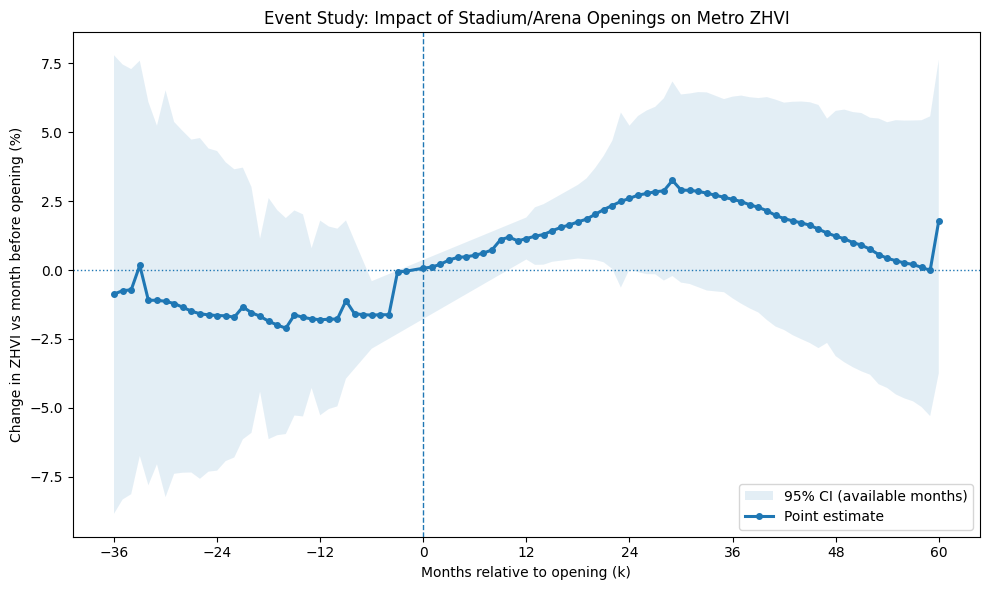

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Filter event window for plotting: k in [-36, 60] ---
es_plot = es_table[
    (es_table["k_months"] >= -36) & (es_table["k_months"] <= 60)
].copy()

# --- 2. Compute 95% CI in % units where SEs exist ---
mask = es_plot["se_log"].notna()

# Initialize CI columns
es_plot["ci_low_pct"] = np.nan
es_plot["ci_high_pct"] = np.nan

coefs = es_plot.loc[mask, "coef_log"]
ses = es_plot.loc[mask, "se_log"]

# log → % transform
ci_low = 100 * (np.exp(coefs - 1.96 * ses) - 1)
ci_high = 100 * (np.exp(coefs + 1.96 * ses) - 1)

es_plot.loc[mask, "ci_low_pct"] = ci_low
es_plot.loc[mask, "ci_high_pct"] = ci_high

# --- 3. Create figure ---
fig, ax = plt.subplots(figsize=(10, 6))

x = es_plot["k_months"].values
y = es_plot["pct_change_vs_km1"].values

# --- 4. Plot CI band where available ---
has_ci = es_plot["ci_low_pct"].notna()

ax.fill_between(
    x[has_ci],
    es_plot.loc[has_ci, "ci_low_pct"],
    es_plot.loc[has_ci, "ci_high_pct"],
    alpha=0.12,          # thinner shading
    linewidth=0.5,
    label="95% CI (available months)"
)

# --- 5. Plot line + points ---
ax.plot(
    x,
    y,
    marker="o",
    linewidth=2.2,        # thicker line for readability
    markersize=4,
    label="Point estimate"
)

# --- 6. Reference lines ---
ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle=":", linewidth=1)

# --- 7. Labels and title ---
ax.set_xlabel("Months relative to opening (k)")
ax.set_ylabel("Change in ZHVI vs month before opening (%)")
ax.set_title("Event Study: Impact of Stadium/Arena Openings on Metro ZHVI")

ax.legend()

# X-axis ticks every 12 months
ax.set_xticks(range(-36, 61, 12))

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# === 1. Fresh load so we don't inherit old df state ===
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"
df_yr = pd.read_csv(CSV)

# === 2. Basic setup: ln_zhvi and first opening per metro ===
needed = ["metro_name", "ym", "zhvi", "open_ym"]
missing = [c for c in needed if c not in df_yr.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_yr["ym"] = pd.to_datetime(df_yr["ym"])
df_yr["open_ym"] = pd.to_datetime(df_yr["open_ym"])

# Keep only positive ZHVI and build log outcome
df_yr = df_yr[df_yr["zhvi"] > 0].copy()
df_yr["ln_zhvi"] = np.log(df_yr["zhvi"])

# First opening month per metro (if any)
first_open_per_metro = (
    df_yr.dropna(subset=["open_ym"])
         .groupby("metro_name")["open_ym"]
         .min()
)
df_yr["first_open_ym"] = df_yr["metro_name"].map(first_open_per_metro)

# === 3. Event time in months (k_months), capped to [-36, 60] ===
ym_num = df_yr["ym"].dt.year * 12 + df_yr["ym"].dt.month
open_num = df_yr["first_open_ym"].dt.year * 12 + df_yr["first_open_ym"].dt.month

k_months = ym_num - open_num  # NaN for never-treated
k_months = k_months.where(~df_yr["first_open_ym"].isna())  # keep NaN for never-treated
k_months = k_months.astype("float")

k_months[k_months < -36] = -36
k_months[k_months >  60] =  60
df_yr["k_months"] = k_months

# === 4. Year bins: event_year = floor(k_months / 12), clipped to [-3, 5] ===
event_year = np.floor(df_yr["k_months"] / 12.0)
event_year = event_year.clip(lower=-3, upper=5)
df_yr["event_year"] = event_year

# === 5. Build year-bin dummies (reference: event_year = -1) ===
# We'll estimate bins for: -3, -2, 0, 1, 2, 3, 4, 5
year_bins = [-3, -2, 0, 1, 2, 3, 4, 5]

for j in year_bins:
    df_yr[f"ey_{j}"] = (df_yr["event_year"] == j).fillna(False).astype(int)

# We do NOT create a dummy for -1; it is the omitted reference period (−12 to −1 months)

# === 6. Set panel index BEFORE constructing y and X ===
df_yr = df_yr.set_index(["metro_name", "ym"]).sort_index()

y = df_yr["ln_zhvi"]
X = df_yr[[f"ey_{j}" for j in year_bins]]

# Sanity check shapes
print("y shape:", y.shape)
print("X shape:", X.shape)

# === 7. Run year-binned event study ===
mod_year_es = PanelOLS(y, X, entity_effects=True, time_effects=True)
res_year_es = mod_year_es.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)

print("\n=== Year-Binned Event Study ===")
print("ln(ZHVI_mt) on event-year bins, metro FE + month FE")
print("Reference period: event_year = -1 (months -12 to -1)\n")

# === 8. Tidy table with % effects ===
def months_label(j):
    if j == -3:
        return "-36 to -25"
    if j == -2:
        return "-24 to -13"
    if j == -1:
        return "-12 to -1"
    if j == 0:
        return "0 to 11"
    if j == 1:
        return "12 to 23"
    if j == 2:
        return "24 to 35"
    if j == 3:
        return "36 to 47"
    if j == 4:
        return "48 to 59"
    if j == 5:
        return "60+"
    return ""

rows = []
for j in year_bins:
    var = f"ey_{j}"
    if var in res_year_es.params.index:
        coef = res_year_es.params[var]
        se = res_year_es.std_errors[var]
        pval = res_year_es.pvalues[var]
        pct = 100 * (np.exp(coef) - 1)  # % vs year -1
        rows.append({
            "event_year": j,
            "months_range": months_label(j),
            "coef_log": coef,
            "se_log": se,
            "p_value": pval,
            "pct_change_vs_year_minus1": pct
        })

year_es_table = pd.DataFrame(rows).sort_values("event_year")

print(year_es_table.to_string(index=False))

print("\nNotes:")
print("- event_year is floor(k_months / 12), capped to [-3, 5].")
print("- event_year = -1 (months -12 to -1) is the omitted reference year.")
print("- Coefficients are log points; pct_change_vs_year_minus1 = 100·(exp(θ_j) − 1).")
print("- All specs include metro and month fixed effects; SEs two-way clustered by metro and month.")

y shape: (105824,)
X shape: (105824, 8)

=== Year-Binned Event Study ===
ln(ZHVI_mt) on event-year bins, metro FE + month FE
Reference period: event_year = -1 (months -12 to -1)

 event_year months_range  coef_log   se_log  p_value  pct_change_vs_year_minus1
         -3   -36 to -25 -0.015799 0.028158 0.574741                  -1.567465
         -2   -24 to -13 -0.005379 0.015866 0.734578                  -0.536476
          0      0 to 11  0.017575 0.011027 0.110991                   1.772984
          1     12 to 23  0.029110 0.016728 0.081821                   2.953834
          2     24 to 35  0.039655 0.021011 0.059116                   4.045218
          3     36 to 47  0.031333 0.022831 0.169941                   3.182869
          4     48 to 59  0.017537 0.026657 0.510624                   1.769146
          5          60+  0.028922 0.026854 0.281486                   2.934399

Notes:
- event_year is floor(k_months / 12), capped to [-3, 5].
- event_year = -1 (months -12 to -1)

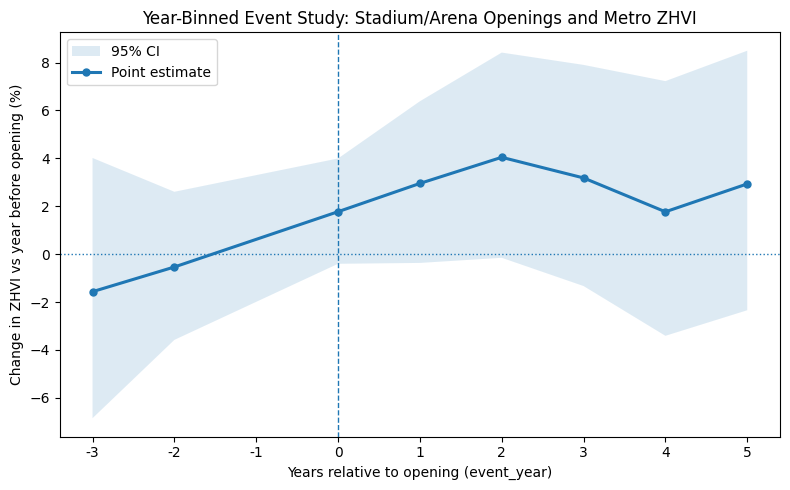

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Copy table so we don't accidentally mutate the original ---
plot_df = year_es_table.copy()

# --- 2. Compute 95% CI in % units where SEs exist ---
mask = plot_df["se_log"].notna()

plot_df["ci_low_pct"] = np.nan
plot_df["ci_high_pct"] = np.nan

coefs = plot_df.loc[mask, "coef_log"]
ses = plot_df.loc[mask, "se_log"]

# CIs on log scale, then convert to %
ci_low = 100 * (np.exp(coefs - 1.96 * ses) - 1)
ci_high = 100 * (np.exp(coefs + 1.96 * ses) - 1)

plot_df.loc[mask, "ci_low_pct"] = ci_low
plot_df.loc[mask, "ci_high_pct"] = ci_high

# --- 3. X = event_year bins, Y = % change vs year -1 ---
x = plot_df["event_year"].values
y = plot_df["pct_change_vs_year_minus1"].values

fig, ax = plt.subplots(figsize=(8, 5))

# --- 4. Plot CI band where available ---
has_ci = plot_df["ci_low_pct"].notna()

ax.fill_between(
    x[has_ci],
    plot_df.loc[has_ci, "ci_low_pct"],
    plot_df.loc[has_ci, "ci_high_pct"],
    alpha=0.15,
    linewidth=0.5,
    label="95% CI"
)

# --- 5. Plot line + points ---
ax.plot(
    x,
    y,
    marker="o",
    linewidth=2.2,
    markersize=5,
    label="Point estimate"
)

# --- 6. Reference lines ---
ax.axvline(0, linestyle="--", linewidth=1)
ax.axhline(0, linestyle=":", linewidth=1)

# --- 7. Axis labels & title ---
ax.set_xlabel("Years relative to opening (event_year)")
ax.set_ylabel("Change in ZHVI vs year before opening (%)")
ax.set_title("Year-Binned Event Study: Stadium/Arena Openings and Metro ZHVI")

# Show ticks for -3,...,5 (even though -1 is omitted from regression)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3, 4, 5])
ax.set_xticklabels(["-3", "-2", "-1", "0", "1", "2", "3", "4", "5"])

ax.legend()
plt.tight_layout()
plt.show()

y shape: (105824,)
X shape: (105824, 32)

=== Quarter-Binned Event Study ===
ln(ZHVI_mt) on 3-month event-time bins, metro FE + month FE
Reference bin: event_quarter = -1 (months -3 to -1)

 event_quarter months_range  coef_log   se_log  p_value  pct_change_vs_qm1
           -12   -36 to -34 -0.030328 0.032658 0.353081          -2.987236
           -11   -33 to -31 -0.006596 0.034243 0.847251          -0.657447
           -10   -30 to -28 -0.011958 0.032547 0.713327          -1.188632
            -9   -27 to -25 -0.015330 0.030466 0.614840          -1.521311
            -8   -24 to -22 -0.016419 0.027666 0.552878          -1.628473
            -7   -21 to -19 -0.014898 0.021796 0.494267          -1.478789
            -6   -18 to -16 -0.019659 0.021771 0.366548          -1.946680
            -5   -15 to -13 -0.016775 0.018076 0.353404          -1.663510
            -4   -12 to -10 -0.017638 0.018229 0.333265          -1.748289
            -3     -9 to -7 -0.014203 0.005590 0.011056     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linearmodels/panel/results.py:89: RuntimeWarning: invalid value encountered in sqrt
  return Series(np.sqrt(np.diag(self.cov)), self._var_names, name="std_error")


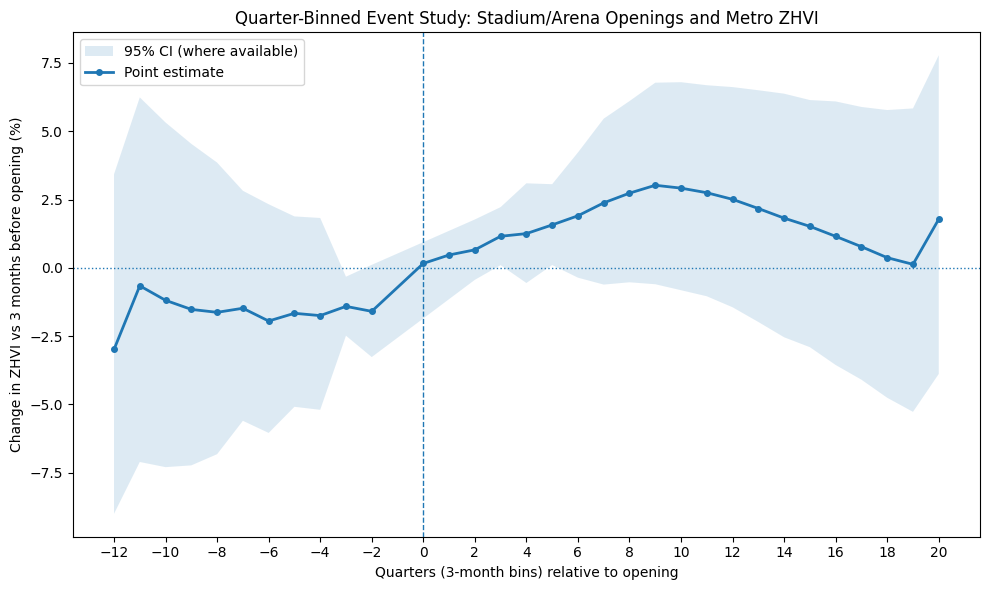

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# === 1. Fresh load: metro–month panel ===
CSV = r"/Users/mickeynguyen/Documents/School /Stadium Paper/Output/zhvi_metro_month_with_openings.csv"
df_q = pd.read_csv(CSV)

# --- Basic checks and parsing ---
needed = ["metro_name", "ym", "zhvi", "open_ym"]
missing = [c for c in needed if c not in df_q.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df_q["ym"] = pd.to_datetime(df_q["ym"])
df_q["open_ym"] = pd.to_datetime(df_q["open_ym"])

# Keep only positive ZHVI and log it
df_q = df_q[df_q["zhvi"] > 0].copy()
df_q["ln_zhvi"] = np.log(df_q["zhvi"])

# === 2. First opening month per metro (if any) ===
first_open_per_metro = (
    df_q.dropna(subset=["open_ym"])
        .groupby("metro_name")["open_ym"]
        .min()
)
df_q["first_open_ym"] = df_q["metro_name"].map(first_open_per_metro)

# === 3. Event time in months, k_months ∈ [-36, 60] ===
ym_num = df_q["ym"].dt.year * 12 + df_q["ym"].dt.month
open_num = df_q["first_open_ym"].dt.year * 12 + df_q["first_open_ym"].dt.month

k_months = ym_num - open_num                 # NaN for never-treated
k_months = k_months.where(~df_q["first_open_ym"].isna())
k_months = k_months.astype(float)

k_months[k_months < -36] = -36
k_months[k_months >  60] =  60
df_q["k_months"] = k_months

# === 4. Quarter bins: event_quarter = floor(k/3), as integer ===
# Each "quarter" is a 3-month bin relative to opening
event_quarter = np.floor(df_q["k_months"] / 3.0)
event_quarter = event_quarter.clip(lower=-12, upper=20).astype("Int64")
df_q["event_quarter"] = event_quarter

# Reference bin: event_quarter = -1 (months -3 to -1)

# === 5. Quarter dummies ===
# get_dummies will create columns like "eq_-3", "eq_0", etc.
q_dummies = pd.get_dummies(df_q["event_quarter"], prefix="eq")
df_q = pd.concat([df_q, q_dummies], axis=1)

# All observed quarter bins except -1 (the reference)
quarters = sorted(int(q) for q in df_q["event_quarter"].dropna().unique())
quarters = [q for q in quarters if q != -1]

X_cols = [f"eq_{q}" for q in quarters]

# === 6. Set panel index and define y, X ===
df_q = df_q.set_index(["metro_name", "ym"]).sort_index()

y = df_q["ln_zhvi"]
X = df_q[X_cols]

print("y shape:", y.shape)
print("X shape:", X.shape)

# === 7. Run quarter-binned event-study regression ===
mod_q = PanelOLS(y, X, entity_effects=True, time_effects=True)
res_q = mod_q.fit(cov_type="clustered", cluster_entity=True, cluster_time=True)

print("\n=== Quarter-Binned Event Study ===")
print("ln(ZHVI_mt) on 3-month event-time bins, metro FE + month FE")
print("Reference bin: event_quarter = -1 (months -3 to -1)\n")

# === 8. Build tidy table with % effects vs quarter -1 ===
rows = []
for q in quarters:
    var = f"eq_{q}"
    if var in res_q.params.index:
        coef = res_q.params[var]
        se = res_q.std_errors[var]
        pval = res_q.pvalues[var]
        pct = 100 * (np.exp(coef) - 1)

        # Approximate month range for this quarter (clipped to [-36, 60])
        lo = max(-36, 3 * q)
        hi = min(60, lo + 2)
        months_range = f"{lo} to {hi}"

        rows.append({
            "event_quarter": q,
            "months_range": months_range,
            "coef_log": coef,
            "se_log": se,
            "p_value": pval,
            "pct_change_vs_qm1": pct
        })

q_es_table = pd.DataFrame(rows).sort_values("event_quarter")
print(q_es_table.to_string(index=False))

print("\nNotes:")
print("- event_quarter = floor(k_months / 3), so each bin is 3 months.")
print("- Bin -1 (months -3 to -1) is the omitted pre-period.")
print("- pct_change_vs_qm1 = 100·(exp(θ_q) − 1): % vs the 3 months before opening.")
print("- All specs include metro and month FE; SEs two-way clustered by metro and month.\n")

# === 9. Plot quarter-binned ES ===
plot_df = q_es_table.copy()
mask = plot_df["se_log"].notna()

plot_df["ci_low_pct"] = np.nan
plot_df["ci_high_pct"] = np.nan

coefs = plot_df.loc[mask, "coef_log"]
ses = plot_df.loc[mask, "se_log"]

ci_low = 100 * (np.exp(coefs - 1.96 * ses) - 1)
ci_high = 100 * (np.exp(coefs + 1.96 * ses) - 1)

plot_df.loc[mask, "ci_low_pct"] = ci_low
plot_df.loc[mask, "ci_high_pct"] = ci_high

x = plot_df["event_quarter"].values
y_pct = plot_df["pct_change_vs_qm1"].values

fig, ax = plt.subplots(figsize=(10, 6))

has_ci = plot_df["ci_low_pct"].notna()
ax.fill_between(
    x[has_ci],
    plot_df.loc[has_ci, "ci_low_pct"],
    plot_df.loc[has_ci, "ci_high_pct"],
    alpha=0.15,
    linewidth=0.5,
    label="95% CI (where available)"
)

ax.plot(
    x, y_pct,
    marker="o",
    linewidth=2.0,
    markersize=4,
    label="Point estimate"
)

ax.axvline(0, linestyle="--", linewidth=1)   # opening quarter
ax.axhline(0, linestyle=":", linewidth=1)    # zero effect

ax.set_xlabel("Quarters (3-month bins) relative to opening")
ax.set_ylabel("Change in ZHVI vs 3 months before opening (%)")
ax.set_title("Quarter-Binned Event Study: Stadium/Arena Openings and Metro ZHVI")

# Optional: x-ticks every 2 quarters for readability
xmin, xmax = int(plot_df["event_quarter"].min()), int(plot_df["event_quarter"].max())
ax.set_xticks(range(xmin, xmax + 1, 2))

ax.legend()
plt.tight_layout()
plt.show()